# CST8507 Lab 1: Zipf's Law and Text Analysis

**Author:** Peng Wang  
**Section:** 101  
**Date:** 2026-01-20

## Description

This program analyzes word frequency distributions in two different text corpora (literary and informational) to empirically verify Zipf's Law. It performs tokenization, frequency analysis, and comparative studies including stability testing with stopword removal and part-of-speech filtering.

## Innovations

- Automated comparative analysis with statistical metrics
- Comprehensive visualization with multiple subplots
- Robust preprocessing pipeline with error handling

## Step 1: Import required libraries

In [21]:
import string
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
from nltk.corpus import gutenberg, stopwords
from scipy import stats

# Ensure required NLTK data is available
# Uncomment these lines on first run to download necessary data
# nltk.download('gutenberg')
# nltk.download('punkt')
# nltk.download('stopwords')
# nltk.download('averaged_perceptron_tagger')





def tokenize_and_clean(text):
    """
    Tokenize text and perform basic cleaning.
    
    Args:
        text (str): Raw text to tokenize
    
    Returns:
        list: List of cleaned tokens (lowercase, alphabetic only)
    """
    # Tokenize the text
    tokens = word_tokenize(text)
    
    # Clean tokens: lowercase and keep only alphabetic words
    cleaned_tokens = [token.lower() for token in tokens 
                     if token.isalpha()]
    
    return cleaned_tokens


def analyze_frequency(tokens):
    """
    Analyze word frequency distribution.
    
    Args:
        tokens (list): List of word tokens
    
    Returns:
        tuple: (FreqDist object, sorted list of (word, frequency) tuples, DataFrame)
    """
    # Create frequency distribution
    fdist = FreqDist(tokens)
    
    # Sort by frequency (descending)
    sorted_fdist = sorted(fdist.items(), key=lambda x: x[1], reverse=True)
    
    # Create DataFrame for analysis
    df = pd.DataFrame(sorted_fdist, columns=['word', 'frequency'])
    df['rank'] = range(1, len(df) + 1)
    
    return fdist, sorted_fdist, df


def calculate_zipf_metrics(df):
    """
    Calculate Zipf's Law metrics including exponent and R-squared.
    
    Args:
        df (DataFrame): DataFrame with 'rank' and 'frequency' columns
    
    Returns:
        tuple: (slope/alpha, R-squared value)
    """
    # Take logarithm of rank and frequency
    log_rank = np.log(df['rank'])
    log_freq = np.log(df['frequency'])
    
    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(log_rank, log_freq)
    
    return -slope, r_value**2


def plot_zipf_distribution(df, title, ax=None):
    """
    Plot Zipf's Law distribution on log-log scale.
    
    Args:
        df (DataFrame): DataFrame with 'rank' and 'frequency' columns
        title (str): Plot title
        ax (matplotlib.axes): Axes object for subplot (optional)
    
    Returns:
        None
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.loglog(df['rank'], df['frequency'], 'bo', markersize=3)
    ax.set_xlabel('Rank (log scale)', fontsize=12)
    ax.set_ylabel('Frequency (log scale)', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, which='both')
    
    if ax is None:
        plt.tight_layout()
        plt.show()


def remove_stopwords(tokens):
    """
    Remove English stopwords from token list.
    
    Args:
        tokens (list): List of word tokens
    
    Returns:
        list: Tokens with stopwords removed
    """
    stop_words = set(stopwords.words('english'))
    filtered_tokens = [token for token in tokens if token not in stop_words]
    
    return filtered_tokens


def extract_nouns(tokens):
    """
    Extract only nouns from token list using POS tagging.
    
    Args:
        tokens (list): List of word tokens
    
    Returns:
        list: List of noun tokens only
    """
    # Perform POS tagging
    pos_tags = nltk.pos_tag(tokens)
    
    # Extract nouns (NN, NNS, NNP, NNPS)
    nouns = [word for word, pos in pos_tags if pos.startswith('NN')]
    
    return nouns

## Step 2: Load and prepare data

In [22]:
print("=" * 70)
print("CST8507 Lab 1: Zipf's Law Analysis")
print("=" * 70)
print("\nStep 2: Loading text data...")

# Load literary text (Jane Austen's Emma)
literary_text = gutenberg.raw('austen-emma.txt')
print(f"Literary text loaded: {len(literary_text)} characters")

# Load informational text (King James Bible)
informational_text = gutenberg.raw('bible-kjv.txt')
print(f"Informational text loaded: {len(informational_text)} characters")

CST8507 Lab 1: Zipf's Law Analysis

Step 2: Loading text data...
Literary text loaded: 887071 characters
Informational text loaded: 4332554 characters


## Step 3: Tokenize the data

In [23]:
print("\nStep 3: Tokenizing and cleaning data...")

literary_tokens = tokenize_and_clean(literary_text)
print(f"Literary tokens: {len(literary_tokens)} words")

informational_tokens = tokenize_and_clean(informational_text)
print(f"Informational tokens: {len(informational_tokens)} words")


Step 3: Tokenizing and cleaning data...
Literary tokens: 157114 words
Informational tokens: 790192 words


## Step 4: Analyze word frequencies

In [24]:
print("\nStep 4: Analyzing word frequencies...")

# Analyze literary text
lit_fdist, lit_sorted, lit_df = analyze_frequency(literary_tokens)
print(f"\nLiterary Text Analysis:")
print(f"  Total vocabulary size: {len(lit_fdist)}")
print(f"  Top 20 most frequent words:")
for i, (word, freq) in enumerate(lit_sorted[:20], 1):
    print(f"    {i:2d}. {word:15s} - {freq:5d}")

# Analyze informational text
info_fdist, info_sorted, info_df = analyze_frequency(informational_tokens)
print(f"\nInformational Text Analysis:")
print(f"  Total vocabulary size: {len(info_fdist)}")
print(f"  Top 20 most frequent words:")
for i, (word, freq) in enumerate(info_sorted[:20], 1):
    print(f"    {i:2d}. {word:15s} - {freq:5d}")

# Calculate Zipf metrics
lit_alpha, lit_r2 = calculate_zipf_metrics(lit_df)
info_alpha, info_r2 = calculate_zipf_metrics(info_df)

print(f"\nZipf's Law Metrics:")
print(f"  Literary text - Alpha: {lit_alpha:.3f}, R-squared: {lit_r2:.3f}")
print(f"  Informational text - Alpha: {info_alpha:.3f}, R-squared: {info_r2:.3f}")


Step 4: Analyzing word frequencies...

Literary Text Analysis:
  Total vocabulary size: 6932
  Top 20 most frequent words:
     1. the             -  5201
     2. to              -  5181
     3. and             -  4877
     4. of              -  4284
     5. i               -  3177
     6. a               -  3124
     7. it              -  2503
     8. her             -  2448
     9. was             -  2396
    10. she             -  2336
    11. not             -  2281
    12. in              -  2173
    13. be              -  1970
    14. you             -  1967
    15. he              -  1806
    16. that            -  1805
    17. had             -  1623
    18. but             -  1441
    19. as              -  1436
    20. for             -  1346

Informational Text Analysis:
  Total vocabulary size: 12561
  Top 20 most frequent words:
     1. the             - 64023
     2. and             - 51696
     3. of              - 34670
     4. to              - 13580
     5. that     

## Step 5: Plot Zipf distributions for both texts


Step 4 (continued): Plotting Zipf distributions...


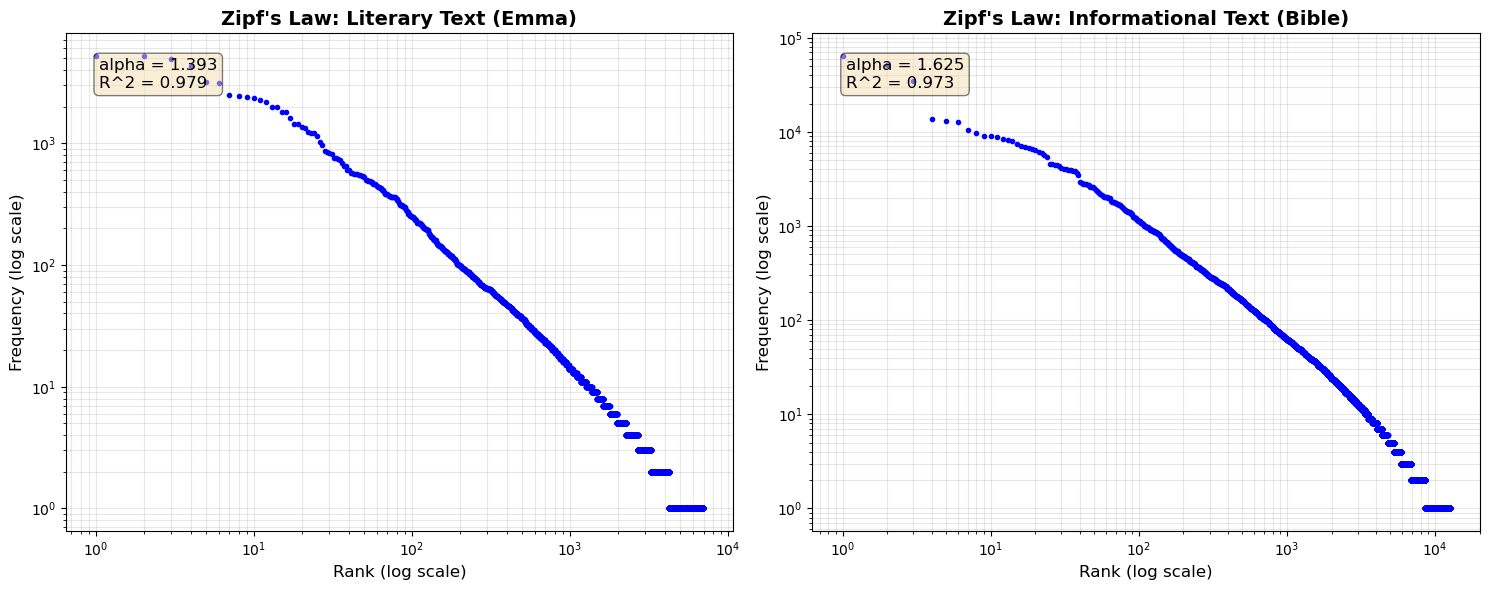

  Plots saved as 'images/zipf_comparison.png'
  [Image Data] Literary: alpha = 1.393, R^2 = 0.979
  [Image Data] Informational: alpha = 1.625, R^2 = 0.973


In [25]:
print("\nStep 4 (continued): Plotting Zipf distributions...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

plot_zipf_distribution(lit_df, "Zipf's Law: Literary Text (Emma)", ax1)
ax1.text(0.05, 0.95, f'alpha = {lit_alpha:.3f}\nR^2 = {lit_r2:.3f}', 
         transform=ax1.transAxes, fontsize=12, 
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plot_zipf_distribution(info_df, "Zipf's Law: Informational Text (Bible)", ax2)
ax2.text(0.05, 0.95, f'alpha = {info_alpha:.3f}\nR^2 = {info_r2:.3f}', 
         transform=ax2.transAxes, fontsize=12, 
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('images/zipf_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("  Plots saved as 'images/zipf_comparison.png'")
print(f"  [Image Data] Literary: alpha = {lit_alpha:.3f}, R^2 = {lit_r2:.3f}")
print(f"  [Image Data] Informational: alpha = {info_alpha:.3f}, R^2 = {info_r2:.3f}")

## Step 6: Stability testing - Remove stopwords


Step 6: Evaluating stability - Removing stopwords...
Tokens after stopword removal: 69693
Zipf metrics without stopwords:
  Alpha: 1.244, R-squared: 0.958
  Change in alpha: -0.149

Generating comparison plot: Original vs Without Stopwords...


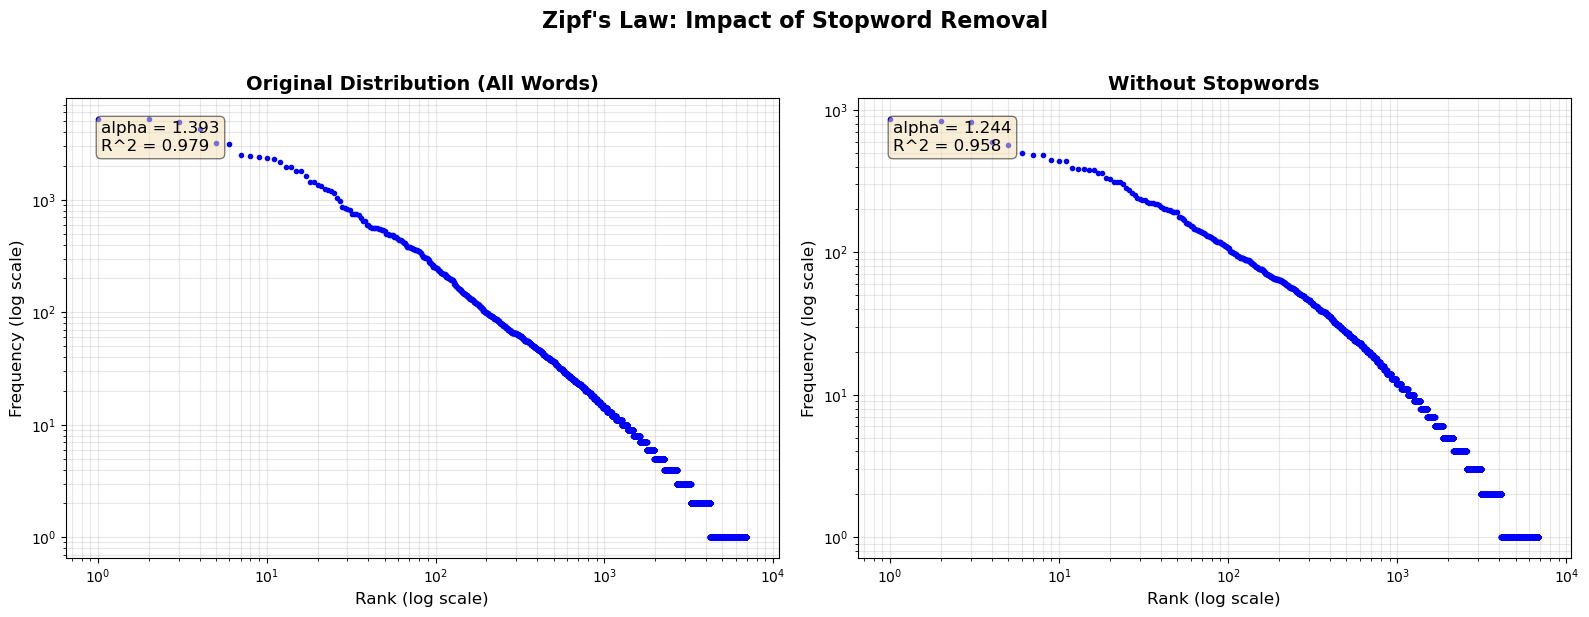

  Comparison plot saved as 'images/zipf_stopword_comparison.png'
  [Image Data] Original: alpha = 1.393, R^2 = 0.979
  [Image Data] Without Stopwords: alpha = 1.244, R^2 = 0.958

Comparison Summary:
  Original:          alpha = 1.393, R^2 = 0.979
  Without Stopwords: alpha = 1.244, R^2 = 0.958
  Change in alpha:   -0.149
  Change in R^2:     -0.020


In [26]:
print("\nStep 6: Evaluating stability - Removing stopwords...")

# Use literary text for stability testing
lit_no_stop = remove_stopwords(literary_tokens)
print(f"Tokens after stopword removal: {len(lit_no_stop)}")

# Analyze frequency without stopwords
_, _, lit_no_stop_df = analyze_frequency(lit_no_stop)
no_stop_alpha, no_stop_r2 = calculate_zipf_metrics(lit_no_stop_df)

print(f"Zipf metrics without stopwords:")
print(f"  Alpha: {no_stop_alpha:.3f}, R-squared: {no_stop_r2:.3f}")
print(f"  Change in alpha: {no_stop_alpha - lit_alpha:+.3f}")


# Plot comparison: Original vs Without Stopwords
print("\nGenerating comparison plot: Original vs Without Stopwords...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Original distribution
plot_zipf_distribution(lit_df, "Original Distribution (All Words)", axes[0])
axes[0].text(0.05, 0.95, f'alpha = {lit_alpha:.3f}\nR^2 = {lit_r2:.3f}', 
             transform=axes[0].transAxes, fontsize=12, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 2: Without stopwords
plot_zipf_distribution(lit_no_stop_df, "Without Stopwords", axes[1])
axes[1].text(0.05, 0.95, f'alpha = {no_stop_alpha:.3f}\nR^2 = {no_stop_r2:.3f}', 
             transform=axes[1].transAxes, fontsize=12, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Zipf\'s Law: Impact of Stopword Removal', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/zipf_stopword_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"  Comparison plot saved as 'images/zipf_stopword_comparison.png'")
print(f"  [Image Data] Original: alpha = {lit_alpha:.3f}, R^2 = {lit_r2:.3f}")
print(f"  [Image Data] Without Stopwords: alpha = {no_stop_alpha:.3f}, R^2 = {no_stop_r2:.3f}")
print(f"\nComparison Summary:")
print(f"  Original:          alpha = {lit_alpha:.3f}, R^2 = {lit_r2:.3f}")
print(f"  Without Stopwords: alpha = {no_stop_alpha:.3f}, R^2 = {no_stop_r2:.3f}")
print(f"  Change in alpha:   {no_stop_alpha - lit_alpha:+.3f}")
print(f"  Change in R^2:     {no_stop_r2 - lit_r2:+.3f}")

## Step 6 (continued): Stability testing - Nouns only


Step 6 (continued): Evaluating stability - Nouns only...
Noun tokens extracted: 28185
Zipf metrics for nouns only:
  Alpha: 1.160, R-squared: 0.961
  Change in alpha: -0.233

Plotting stability comparison...


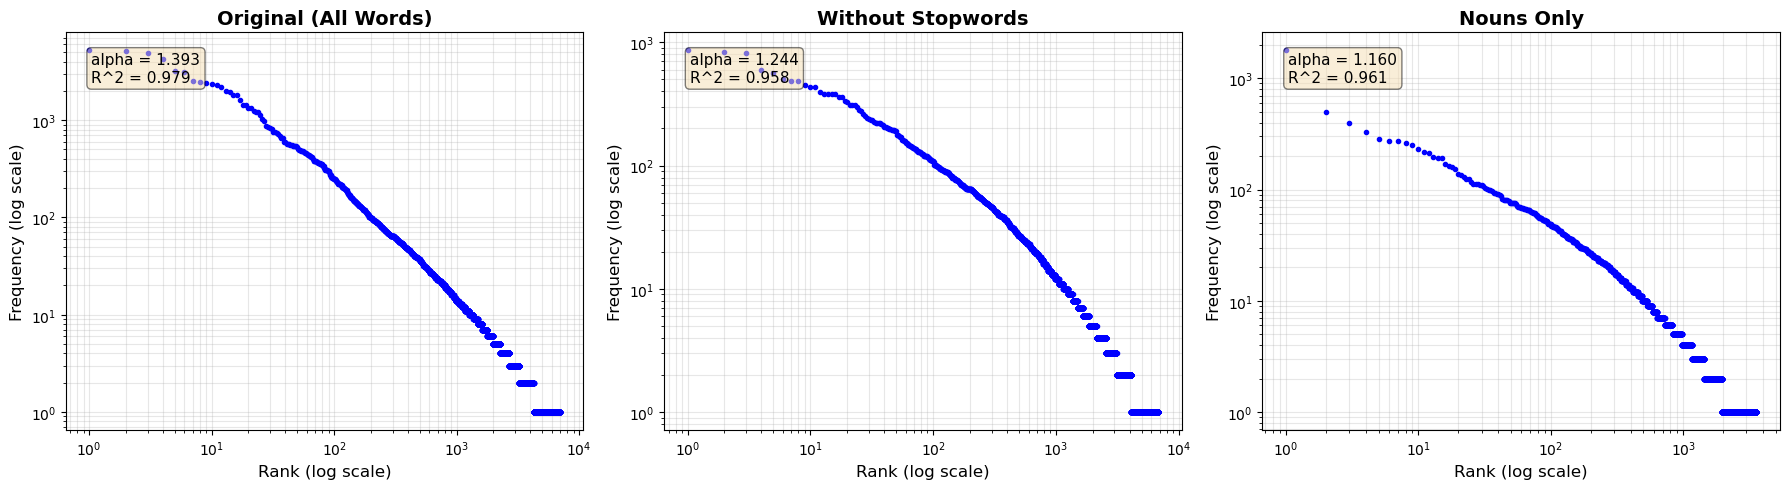

  Stability plots saved as 'images/zipf_stability.png'
  [Image Data] Original: alpha = 1.393, R^2 = 0.979
  [Image Data] Without Stopwords: alpha = 1.244, R^2 = 0.958
  [Image Data] Nouns Only: alpha = 1.160, R^2 = 0.961

Analysis Complete!


In [27]:
print("\nStep 6 (continued): Evaluating stability - Nouns only...")

lit_nouns = extract_nouns(literary_tokens)
print(f"Noun tokens extracted: {len(lit_nouns)}")

# Analyze frequency for nouns only
_, _, lit_nouns_df = analyze_frequency(lit_nouns)
nouns_alpha, nouns_r2 = calculate_zipf_metrics(lit_nouns_df)

print(f"Zipf metrics for nouns only:")
print(f"  Alpha: {nouns_alpha:.3f}, R-squared: {nouns_r2:.3f}")
print(f"  Change in alpha: {nouns_alpha - lit_alpha:+.3f}")


# Plot stability comparison
print("\nPlotting stability comparison...")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_zipf_distribution(lit_df, "Original (All Words)", axes[0])
axes[0].text(0.05, 0.95, f'alpha = {lit_alpha:.3f}\nR^2 = {lit_r2:.3f}', 
             transform=axes[0].transAxes, fontsize=11, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plot_zipf_distribution(lit_no_stop_df, "Without Stopwords", axes[1])
axes[1].text(0.05, 0.95, f'alpha = {no_stop_alpha:.3f}\nR^2 = {no_stop_r2:.3f}', 
             transform=axes[1].transAxes, fontsize=11, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plot_zipf_distribution(lit_nouns_df, "Nouns Only", axes[2])
axes[2].text(0.05, 0.95, f'alpha = {nouns_alpha:.3f}\nR^2 = {nouns_r2:.3f}', 
             transform=axes[2].transAxes, fontsize=11, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('images/zipf_stability.png', dpi=300, bbox_inches='tight')
plt.show()

print("  Stability plots saved as 'images/zipf_stability.png'")
print(f"  [Image Data] Original: alpha = {lit_alpha:.3f}, R^2 = {lit_r2:.3f}")
print(f"  [Image Data] Without Stopwords: alpha = {no_stop_alpha:.3f}, R^2 = {no_stop_r2:.3f}")
print(f"  [Image Data] Nouns Only: alpha = {nouns_alpha:.3f}, R^2 = {nouns_r2:.3f}")


print("\n" + "=" * 70)
print("Analysis Complete!")
print("=" * 70)